# PAC Plots: siganl vs background
This notebook contains calculations / plots for September 2026 PAC. The goal is to generate simulated signal over backgroudnd chart for run1a/run1b scenarios. 1809 keV, and then 347 keV photons are focused

In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants

In [2]:
nPOT = 1.0e12

# run1a/b, all to VD101
event_dict = {
    "MuBeam1a":{
        "file": "tmp/mu101_MDC2025ai_dump.root",
        "nEvent": 3642.,
        "weight": 1./1000000000.*213816./100000000.*nPOT, # multiple event # by this
    },
    "EleBeam1a":{
        "file": "tmp/ele101_MDC2025ai_dump.root",
        "nEvent": 37913.,
        "weight": 1./5441845688.*5532579./100000000.*nPOT, # multiple event # by this
    },
    "Neutrals1a":{
        "file": "tmp/neutrals101_MDC2025ag_dump.root",
        "nEvent": 80.,        
        "weight": 1./1983800000.*53426053./100000000.*nPOT, # multiple event # by this
    },
    # 1809 dataset not present for now. Use TargetStops muonstops to generate photons, 
    # number based on solid angle, timing based on capture time, decay time (864.0 ns), and time of flight
    "MuBeam1b":{
        "file": "tmp/mu101_Run1Ban001_dump.root",
        "nEvent": 1366.,
        "weight": 1./897800000.*25584287./2000000000.*nPOT, # multiple event # by this
    },
    "EleBeam1b":{
        "file": "tmp/ele101_Run1Ban001_dump.root",
        "nEvent": 2297.,
        "weight": 1./999600000.*172423754./2000000000.*nPOT, # multiple event # by this
    },
    "1809Beam1b":{
         "file": "tmp/tgtstps101_Run1Ban001_dump.root",
        "nEvent": 105.,
        "weight": 1./1000000000.*79278./2000000000.*1000.*nPOT, # multiple event # by this
    },
}

for k, v in event_dict.items():
    print (k, v["weight"])

MuBeam1a 2.13816
EleBeam1a 10.166732607284471
Neutrals1a 269.31168968646034
MuBeam1b 14.248322009356206
EleBeam1b 86.2463755502201
1809Beam1b 39.639


In [3]:
# For target stops cat, in run1a expected stopped muon number
nMuStopped1a = 1442670./4000000000.*213816./100000000.*1000.*nPOT
n1089 = nMuStopped1a*0.61*0.51
# solid angle extrapolation
def n1809atVD101(radius): #in mm
    r = constants.VD101_Z-(constants.stopping_target_start_Z+constants.stopping_target_end_Z)/2.
    solidangleratio = radius*radius/4/r/r
    return n1089*solidangleratio

In [8]:
# full VD101
hole_radius = 100. #constants.hole1_R 
# now construct 1809 keV plot. Create a ROOT TH1D, with the range of 1809+/-20. 
nNorm = nPOT*np.pi*hole_radius*hole_radius/100. # convert to 1cm^2 equiv.

E_1809     = 1809.
E_halfwin  = 20.
E_sigma    = 2.5     # keV, HPGe resolution
nbins      = 20      
binsize    = 2.*E_halfwin/nbins
hole_X     = constants.VD101_X# + constants.hole1_X  
hole_Y     = 0.#constants.hole1_Y
histmin    = E_1809-E_halfwin
histmax    = E_1809+E_halfwin

EleBeam1a_photon       N(MC)= 32318  chi2/ndf = 223/180 = 1.24  status=0
    p0 (log norm)        =      5.64395 +/- 0.0389072   
    p1 (slope, 1/keV)    =   -0.0030043 +/- 0.000119992 
    p2 (pedestal)        =      34.6555 +/- 0.954667    
    1/e falloff          =      332.856 keV
    corr(p0,p1)          =    -0.875897
    fit prob             =    0.0160843
EleBeam1a_photon       integral: raw(MC)=1.27e+04  fit(weighted)=1.259e+05  resampled(weighted)=1.258e+05
EleBeam1a_photon_tcut  N(MC)=  1109  chi2/ndf = 191.7/180 = 1.06  status=0
    p0 (log norm)        =      2.92162 +/- 0.216807    
    p1 (slope, 1/keV)    =  -0.00428375 +/- 0.000723002 
    p2 (pedestal)        =     0.974192 +/- 0.131258    
    1/e falloff          =       233.44 keV
    corr(p0,p1)          =    -0.924411
    fit prob             =     0.261603
EleBeam1a_photon_tcut  integral: raw(MC)=444  fit(weighted)=4149  resampled(weighted)=4136
EleBeam1a_epm          N(MC)=  4578  chi2/ndf = 194.9/180 = 1.08 

Warning in <TCanvas::Constructor>: Deleting canvas with same name: cEle


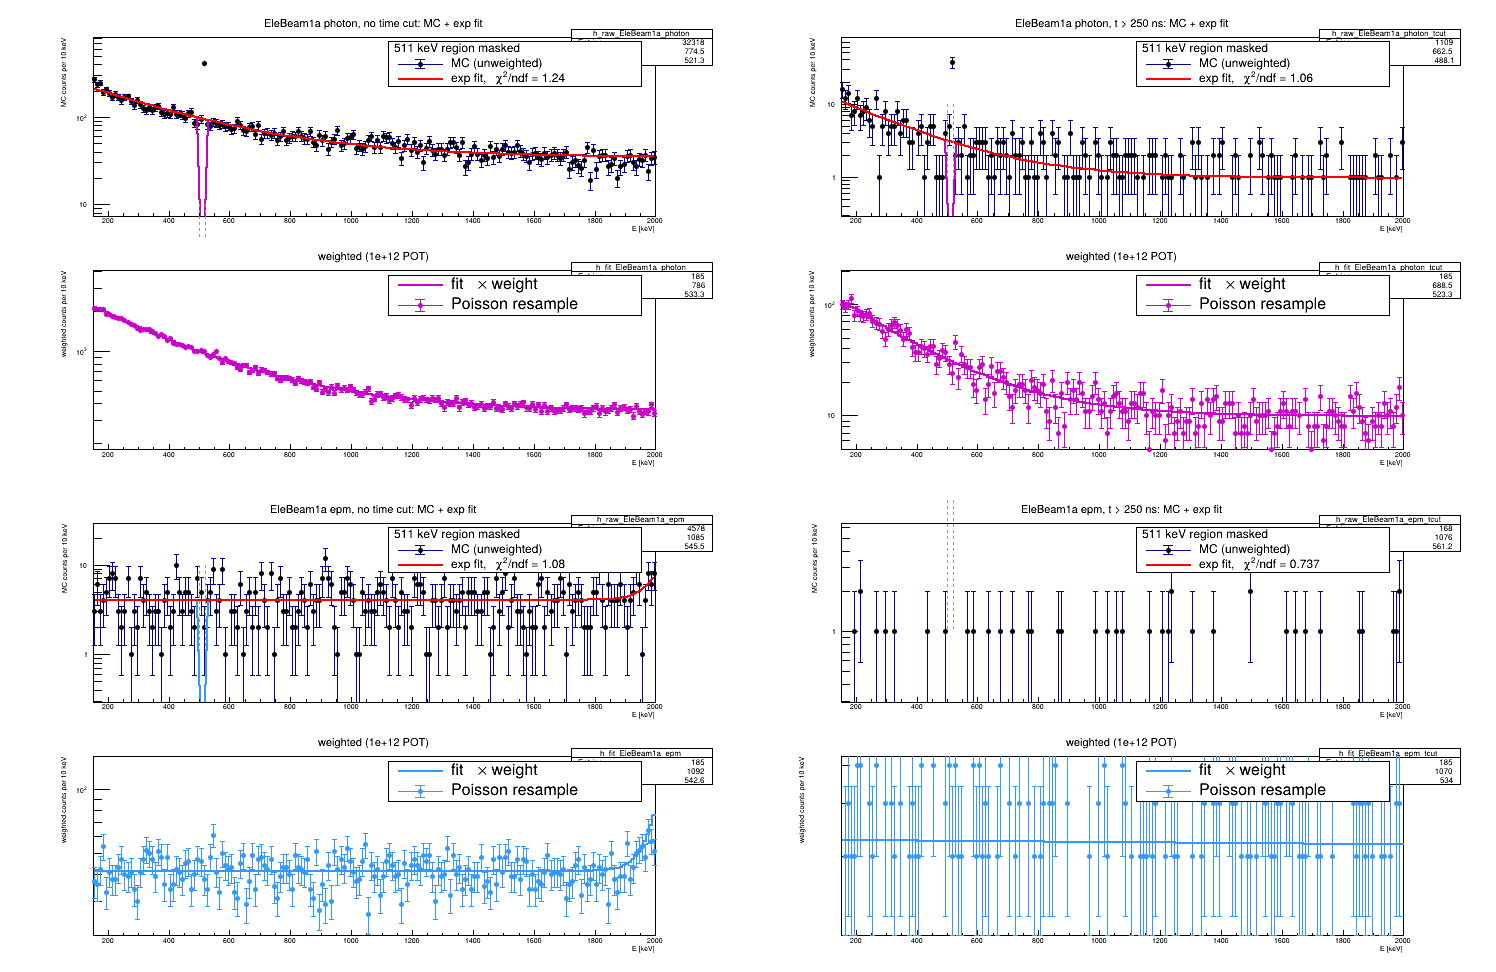

In [9]:
# deal with EleBeam1a first 
# due to the low stat, fit a exponetial to 150 keV - 2000 keV, excluding 500-520 keV
# later resampling uses the poisson smeared number from this fit
# separate photons and e+/-

fit_lo, fit_hi   = 150., 2000.
excl_lo, excl_hi = 500., 520.      # 511 annihilation peak, masked in the fit only
fit_binsize      = 10.
fit_nbins        = int((fit_hi-fit_lo)/fit_binsize)

ele_weight = event_dict["EleBeam1a"]["weight"]

# photons and e+/- treated as two separate groups
groups = {
    "photon": ([22],     ROOT.kMagenta+1),
    "epm":    ([11,-11], ROOT.kAzure+1),
}

# exponential with the 511 region rejected: TH1::Fit has no exclusion-range option,
# so the rejection lives in the fit function itself.
# Cling cannot redefine a function, so only declare it once per kernel session.
try:
    _expo_excl_declared
except NameError:
    ROOT.gInterpreter.Declare("""
    double expo_excl_cpp(double *x, double *par) {
        if (x[0] > %f && x[0] < %f) { TF1::RejectPoint(); return 0.; }
        return std::exp(par[0] + par[1]*x[0]) + par[2];
    }
    """ % (excl_lo, excl_hi))
    _expo_excl_declared = True

def fit_and_resample(tag, group_name, pids, extra_cut = None, seed = 20260807):
    """Unweighted spectrum -> exp fit (511 masked) -> weighted expectation -> per-bin Poisson."""
    v = event_dict[tag]
    pid_cut = "(" + " || ".join("pdgId == %d" % p for p in pids) + ")"

    rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
    rdf = rdf.Filter("virtualdetectorId == 101") \
             .Filter(pid_cut) \
             .Filter("pz > 0.") \
             .Define("Ek", "1000.*E") \
             .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                     % (hole_X, hole_X, hole_Y, hole_Y)) \
             .Filter("dr < %f" % hole_radius)
    if extra_cut is not None:
        rdf = rdf.Filter(extra_cut)

    suffix = "%s_%s%s" % (tag, group_name, "_tcut" if extra_cut else "")

    # 1) raw MC counts, unweighted -- fit uncertainties then reflect true MC statistics
    h_raw = rdf.Histo1D((("h_raw_"+suffix),
                         "%s %s raw MC;E [keV];MC counts per %.0f keV" % (tag, group_name, fit_binsize),
                         fit_nbins, fit_lo, fit_hi), "Ek").GetValue()
    h_raw.SetDirectory(0)

    # 2) fit exponential over the full range with 500-520 keV rejected
    f = ROOT.TF1("f_"+suffix, ROOT.expo_excl_cpp, fit_lo, fit_hi, 3)
    f.SetParameters(np.log(max(h_raw.GetBinContent(1), 1.)), -1./500., 0.)
    f.SetLineColor(groups[group_name][1])

    res = h_raw.Fit(f, "RSQL")
    status = int(res) if res else -1
    ndf = f.GetNDF()
    print("%-22s N(MC)=%6d  chi2/ndf = %.4g/%d = %.3g  status=%d"
          % (suffix, int(h_raw.GetEntries()), f.GetChisquare(), ndf,
             f.GetChisquare()/ndf if ndf > 0 else np.nan, status))

    # full parameter listing: value +/- error, and the correlation between p0 and p1
    par_names = ["p0 (log norm)", "p1 (slope, 1/keV)", "p2 (pedestal)"]
    for ip in range(f.GetNpar()):
        print("    %-20s = %12.6g +/- %-12.6g" % (par_names[ip],
                                                  f.GetParameter(ip), f.GetParError(ip)))
    print("    %-20s = %12.6g keV" % ("1/e falloff", -1./f.GetParameter(1)
                                      if f.GetParameter(1) != 0 else np.nan))
    print("    %-20s = %12.6g" % ("corr(p0,p1)", res.Correlation(0, 1)))
    print("    %-20s = %12.6g" % ("fit prob", f.GetProb()))

    # 3+4) evaluate the fit across the FULL range (500-520 included), weight, Poisson smear.
    #      Weight is applied first; the error and the Poisson draw are taken on the
    #      weighted number, so fluctuations are those of the expected physical event count.
    h_fit  = h_raw.Clone("h_fit_"+suffix)     # fitted expectation, weighted
    h_samp = h_raw.Clone("h_samp_"+suffix)    # Poisson-smeared resample, weighted
    for h in (h_fit, h_samp):
        h.SetDirectory(0)
        h.Reset()
    rng_l = np.random.default_rng(seed)
    p0, p1, p2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    for ib in range(1, fit_nbins+1):
        # weight first, then take the error and the Poisson draw on the weighted number
        mu = (np.exp(p0 + p1*h_raw.GetBinCenter(ib))+p2)*ele_weight
        h_fit.SetBinContent(ib, mu)
        h_fit.SetBinError(ib, np.sqrt(mu))
        n = rng_l.poisson(mu)
        h_samp.SetBinContent(ib, n)
        h_samp.SetBinError(ib, np.sqrt(n))
        
    for h, col in ((h_fit, groups[group_name][1]), (h_samp, groups[group_name][1])):
        h.SetLineColor(col)
    h_samp.SetMarkerStyle(20)
    h_samp.SetMarkerSize(0.6)
    h_samp.SetMarkerColor(groups[group_name][1])
    h_fit.SetLineWidth(2)

    print("%-22s integral: raw(MC)=%.4g  fit(weighted)=%.4g  resampled(weighted)=%.4g"
          % (suffix, h_raw.Integral(), h_fit.Integral(), h_samp.Integral()))
    return {"raw": h_raw, "f": f, "fit": h_fit, "samp": h_samp}

# no time cut, then repeating with time cut t>250 ns
ele_fits = {}
for group_name, (pids, _) in groups.items():
    ele_fits[(group_name, "all")]  = fit_and_resample("EleBeam1a", group_name, pids)
    ele_fits[(group_name, "tcut")] = fit_and_resample("EleBeam1a", group_name, pids,
                                                      extra_cut = "time > 250.")

# draw: rows = photon / e+-, cols = no time cut / t>250 ns
# top of each pad: raw MC spectrum + fitted exponential (the fit itself)
# bottom: weighted expectation + Poisson resample
cEle = ROOT.TCanvas("cEle", "cEle", 1500, 1000)
cEle.Divide(2, 2)
keep = []            # keep TLine/TLegend/TF1 clones alive past the loop
ipad = 0
for group_name in groups:
    for tsel, tlabel in (("all", "no time cut"), ("tcut", "t > 250 ns")):
        ipad += 1
        pad = cEle.cd(ipad)
        pad.Divide(1, 2)

        d = ele_fits[(group_name, tsel)]

        # --- upper: the fit, over the unweighted MC it was fitted to ---
        pad.cd(1)
        gPad.SetLogy()
        d["raw"].SetTitle("EleBeam1a %s, %s: MC + exp fit;E [keV];MC counts per %.0f keV"
                          % (group_name, tlabel, fit_binsize))
        d["raw"].SetMarkerStyle(20)
        d["raw"].SetMarkerSize(0.5)
        d["raw"].Draw("e1")

        # the fitted TF1 rejects 500-520, so draw a clean continuum curve across the full
        # range to show the extrapolation through the masked region
        fdraw = ROOT.TF1("fdraw_%s_%s" % (group_name, tsel), "expo(0)+[2]", fit_lo, fit_hi)
        fdraw.SetParameters(d["f"].GetParameter(0), d["f"].GetParameter(1),
                            d["f"].GetParameter(2))
        fdraw.SetLineColor(ROOT.kRed)
        fdraw.SetLineWidth(2)
        fdraw.Draw("same")
        keep.append(fdraw)

        # shade the masked 511 window
        ymin, ymax = gPad.GetUymin(), gPad.GetUymax()
        for xe in (excl_lo, excl_hi):
            ln = ROOT.TLine(xe, 10**ymin, xe, 10**ymax)
            ln.SetLineColor(ROOT.kGray+1)
            ln.SetLineStyle(2)
            ln.Draw()
            keep.append(ln)

        ndf = d["f"].GetNDF()
        leg1 = ROOT.TLegend(0.52, 0.68, 0.88, 0.88)
        leg1.AddEntry(d["raw"], "MC (unweighted)", "lep")
        leg1.AddEntry(fdraw, "exp fit, #chi^{2}/ndf = %.3g" %
                      (d["f"].GetChisquare()/ndf if ndf > 0 else np.nan), "l")
        leg1.SetHeader("511 keV region masked")
        leg1.Draw()
        keep.append(leg1)

        # --- lower: weighted expectation + Poisson resample ---
        pad.cd(2)
        gPad.SetLogy()
        d["fit"].SetTitle("weighted (%.2g POT);E [keV];weighted counts per %.0f keV"
                          % (nPOT, fit_binsize))
        d["fit"].Draw("hist")
        d["samp"].Draw("e1 same")
        leg2 = ROOT.TLegend(0.52, 0.70, 0.88, 0.88)
        leg2.AddEntry(d["fit"],  "fit #times weight", "l")
        leg2.AddEntry(d["samp"], "Poisson resample", "lep")
        leg2.Draw()
        keep.append(leg2)

cEle.Draw()

N(1809) into hole1 aperture = 509.4 (scale 1.001 x 509 throws)
MuBeam1a     entries in window:     2996, weighted: 14.97
EleBeam1a    entries in window:    36896, weighted: 1647
e-           weighted: 244
e+           weighted: 0
photon       weighted: 1418
S = 509.4, B = 1662, S/B = 0.3065, S/sqrt(B) = 12.49
cross-check: B by source = 1661.98, B by pdgId = 1661.98


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1809


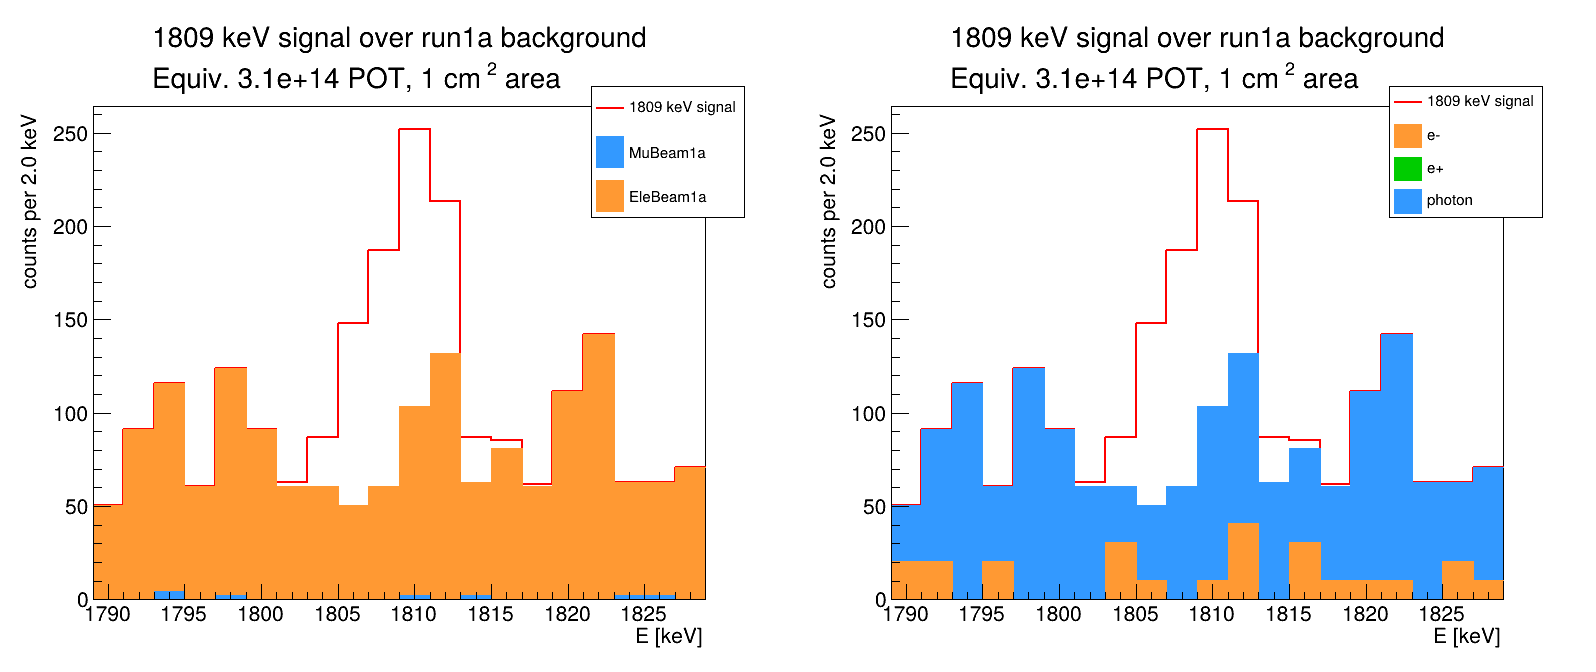

In [37]:
# add signals: fill in the TH1D 
# frist determine number of signals to add. that would be n1809atVD101(hole_radius),
# then generate this many random numbers from a Gaussian distribution with mean 1809, 
# sigma 2.5 keV, and fill in the TH1D.
h_sgnl = ROOT.TH1D("h_1809_sgnl",
                   "1809 keV line;E [keV];counts per %.1f keV" % binsize,
                   nbins, histmin, histmax)
h_sgnl.SetDirectory(0)

nSgnl = n1809atVD101(hole_radius)
# throw a manageable number of samples and scale up, so we do not loop over ~1e6+ throws
nThrow = int(min(nSgnl, 1000000))
sgnl_scale = nSgnl/float(nThrow)
rng = np.random.default_rng(12345)
for E in rng.normal(E_1809, E_sigma, nThrow):
    h_sgnl.Fill(E)
h_sgnl.Scale(sgnl_scale)
print("N(1809) into hole1 aperture = %.4g (scale %.4g x %d throws)" % (nSgnl, sgnl_scale, nThrow))

h_sgnl.SetLineColor(ROOT.kRed)
h_sgnl.SetLineWidth(2)
h_sgnl.SetFillStyle(0)

# add background to the THStack. These coming from "MuBeam1a","EleBeam1a","Neutrals1a"
# open the corresponding ROOT files, get the TTree, use RDataFrame to go through entries
# filter entries that have photons/electrons/positrons going forward into the hole1 aperture,
# in the energy window. Book two breakdowns of the same selection: by source tag, and by pdgId.
bkgd_tags   = ["MuBeam1a", "EleBeam1a"]#, "Neutrals1a"]
tag_colors  = {"MuBeam1a": ROOT.kAzure+1, "EleBeam1a": ROOT.kOrange+1, "Neutrals1a": ROOT.kGreen+2}

pdgId_list   = [22, 11, -11]
pdgId_colors = {22: ROOT.kAzure+1, 11: ROOT.kOrange+1, -11: ROOT.kGreen+1}
pdgId_names  = {22: "photon", 11: "e-", -11: "e+"}
pdgId_cut    = "(" + " || ".join("pdgId == %d" % pid for pid in pdgId_list) + ")"

def book(name, title):
    return ((name, title+";E [keV];counts per %.1f keV" % binsize,
             nbins, histmin, histmax), "Ek")

h_bytag = {}
h_bypid = {pid: None for pid in pdgId_list}

for tag in bkgd_tags:
    v = event_dict[tag]
    rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
    rdf = rdf.Filter("virtualdetectorId == 101") \
             .Filter(pdgId_cut) \
             .Filter("pz > 0.") \
             .Define("Ek", "1000.*E") \
             .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                     % (hole_X, hole_X, hole_Y, hole_Y)) \
             .Filter("dr < %f" % hole_radius)

    # per-source histogram (gamma + e- + e+ together)
    ptr_tag = rdf.Histo1D(*book("h_1809_"+tag, tag))

    # per-pdgId histograms for this source, to be summed across sources below
    ptrs_pid = {pid: rdf.Filter("pdgId == %d" % pid).Histo1D(
                    *book("h_1809_%s_%d" % (tag, pid), pdgId_names[pid]))
                for pid in pdgId_list}

    # single event loop over this file happens here
    h = ptr_tag.GetValue()
    h.SetDirectory(0)
    h.Scale(v["weight"])
    h.SetFillColor(tag_colors[tag])
    h.SetLineColor(tag_colors[tag])
    h_bytag[tag] = h
    print("%-12s entries in window: %8d, weighted: %.4g" % (tag, h.GetEntries(), h.Integral()))

    for pid, ptr in ptrs_pid.items():
        hp = ptr.GetValue()
        hp.SetDirectory(0)
        hp.Scale(v["weight"])
        if h_bypid[pid] is None:
            hp.SetName("h_1809_pid_%d" % pid)
            hp.SetFillColor(pdgId_colors[pid])
            hp.SetLineColor(pdgId_colors[pid])
            h_bypid[pid] = hp
        else:
            h_bypid[pid].Add(hp)

for pid in sorted(h_bypid, key=abs):
    print("%-12s weighted: %.4g" % (pdgId_names[pid], h_bypid[pid].Integral()))

# stack background two ways, overlay signal on each
hs_tag = ROOT.THStack("hs_1809_tag",
                      "#splitline{1809 keV signal over run1a background}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (nNorm, binsize))
for tag in bkgd_tags:
    hs_tag.Add(h_bytag[tag])

hs_pid = ROOT.THStack("hs_1809_pid",
                      "#splitline{1809 keV signal over run1a background}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (nNorm, binsize))
for pid in sorted(h_bypid, key=abs):
    hs_pid.Add(h_bypid[pid])

c1809 = ROOT.TCanvas("c1809", "c1809", 1600, 700)
c1809.Divide(2, 1)

c1809_1 = c1809.cd(1)
c1809_1.SetTopMargin(0.15)
hs_tag.Add(h_sgnl)
hs_tag.Draw("hist")
leg_tag = ROOT.TLegend(0.75, 0.68, 0.95, 0.88)
leg_tag.AddEntry(h_sgnl, "1809 keV signal", "l")
for tag in bkgd_tags:
    leg_tag.AddEntry(h_bytag[tag], tag, "f")
leg_tag.Draw()

c1809_2 = c1809.cd(2)
c1809_2.SetTopMargin(0.15)
hs_pid.Add(h_sgnl)
hs_pid.Draw("hist")
leg_pid = ROOT.TLegend(0.75, 0.68, 0.95, 0.88)
leg_pid.AddEntry(h_sgnl, "1809 keV signal", "l")
for pid in sorted(h_bypid, key=abs):
    leg_pid.AddEntry(h_bypid[pid], pdgId_names[pid], "f")
leg_pid.Draw()

c1809.Draw()

nS = h_sgnl.Integral()
nB = sum(h.Integral() for h in h_bytag.values())
nB_pid = sum(h.Integral() for h in h_bypid.values())
print("S = %.4g, B = %.4g, S/B = %.4g, S/sqrt(B) = %.4g"
      % (nS, nB, nS/nB if nB > 0 else np.inf, nS/np.sqrt(nB) if nB > 0 else np.inf))
print("cross-check: B by source = %.6g, B by pdgId = %.6g" % (nB, nB_pid))

1809 all   MuBeam1a     entries in window:     2996, weighted: 14.97
1809 all   EleBeam1a    from fit, weighted: 1608
1809 all   epm          weighted: 177
1809 all   photon       weighted: 1446
1809 tcut  MuBeam1a     entries in window:     1998, weighted: 12.83
1809 tcut  EleBeam1a    from fit, weighted: 62
1809 tcut  epm          weighted: 9
1809 tcut  photon       weighted: 65.83
1809 all   (no time cut): S = 509.4, B = 1623, S/B = 0.3139, S/sqrt(B) = 12.64
      cross-check: B by source = 1622.97, B by particle = 1622.97
1809 tcut  (t > 250 ns ): S = 463.5, B = 74.83, S/B = 6.195, S/sqrt(B) = 53.58
      cross-check: B by source = 74.829, B by particle = 74.829


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1809


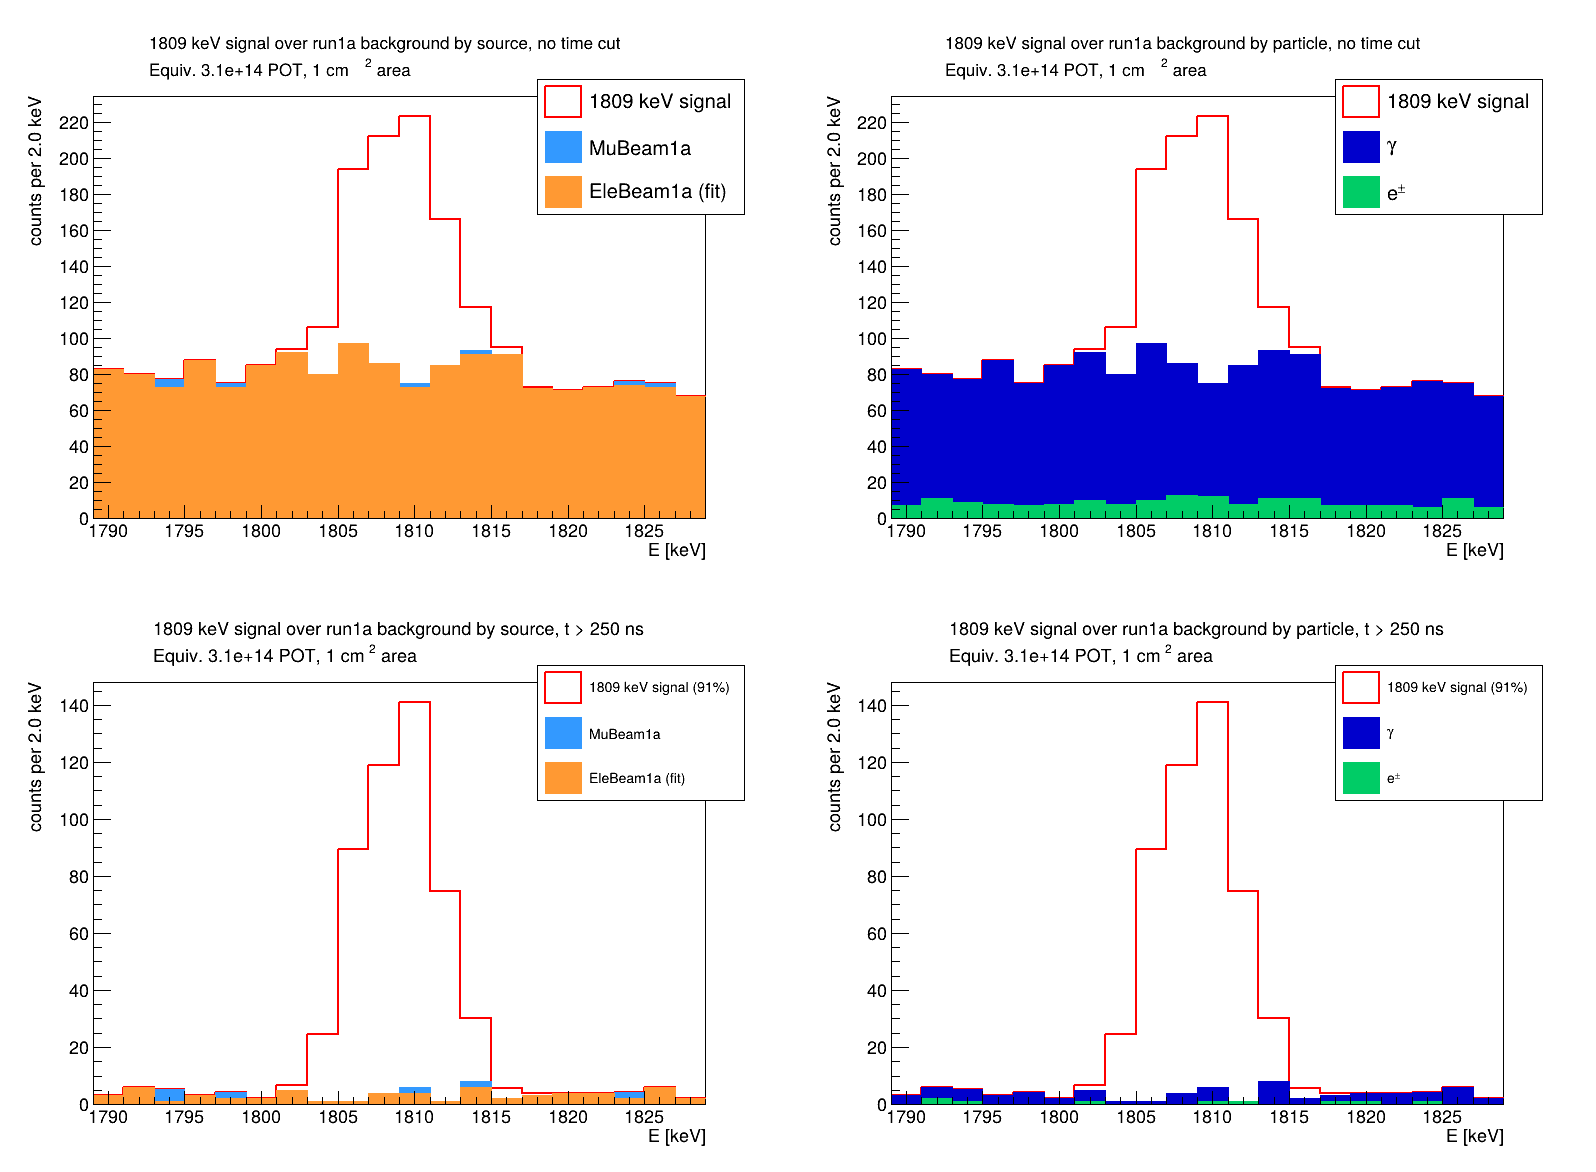

In [40]:
# add background to the THStack. MuBeam1a (and Neutrals1a) come straight from MC;
# EleBeam1a is replaced by the exponential fit + Poisson resample built earlier, since
# its raw MC has too few entries in this window to stack directly.
# Repeated for both time selections: rows = no time cut / t > 250 ns,
# columns = by source / by particle.
mc_tags     = ["MuBeam1a"]#, "Neutrals1a"]
bkgd_tags   = mc_tags + ["EleBeam1a"]
stack_order = ["EleBeam1a"] + mc_tags          # bottom-to-top in the stack
tag_colors  = {"MuBeam1a": ROOT.kAzure+1, "EleBeam1a": ROOT.kOrange+1, "Neutrals1a": ROOT.kGreen+2}

# two particle categories, matching the groups the Ele fit was done in
grp_list   = ["epm", "photon"]
grp_pids   = {"epm": [11, -11], "photon": [22]}
grp_colors = {"epm": ROOT.kTeal+2, "photon": ROOT.kBlue+1}
grp_names  = {"epm": "e^{#pm}", "photon": "#gamma"}
pdgId_cut  = "(pdgId == 22 || pdgId == 11 || pdgId == -11)"

# time selections: rows of the final 2x2. 91% of the 1809 signal survives t > 250 ns.
sgnl_eff  = {"all": 1.00, "tcut": 0.91}
tsel_list = [("all",  None,          "no time cut"),
             ("tcut", "time > 250.", "t > 250 ns")]

def book(name, title):
    return ((name, title+";E [keV];counts per %.1f keV" % binsize,
             nbins, histmin, histmax), "Ek")

# ---- EleBeam1a from the fit, regenerated on THIS histogram's binning ----
# ele_fits histograms use fit_binsize over 150-2000 keV, which does not line up with the
# 1809 grid, so re-evaluate the fitted function per bin here and Poisson-smear on that grid.
# Weight is applied first; the Poisson draw and error are taken on the weighted number.
def ele_from_fit(name, group_name, tsel, color, rng_l):
    d = ele_fits[(group_name, tsel)]
    f = d["f"]
    p0, p1, p2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    h = ROOT.TH1D(name, "EleBeam1a %s (fit);E [keV];counts per %.1f keV" % (group_name, binsize),
                  nbins, histmin, histmax)
    h.SetDirectory(0)
    for ib in range(1, nbins+1):
        # fit was made per fit_binsize; rescale the density to this bin width
        mu = (np.exp(p0 + p1*h.GetBinCenter(ib)) + p2)*ele_weight*(binsize/fit_binsize)
        mu = max(mu, 0.)
        n = rng_l.poisson(mu)
        h.SetBinContent(ib, n)
        h.SetBinError(ib, np.sqrt(n))
    h.SetFillColor(color)
    h.SetLineColor(color)
    return h

h_bytag  = {}   # (tsel, tag)   -> TH1D
h_bygrp  = {}   # (tsel, group) -> TH1D
h_sgnl_t = {}   # tsel -> TH1D

for tsel, tcut, tlabel in tsel_list:
    rng_l = np.random.default_rng(90210)   # same seed per row: row differences are the model, not the throw

    # --- signal: same Gaussian shape, scaled by the surviving fraction ---
    hsig = h_sgnl.Clone("h_1809_sgnl_%s" % tsel)
    hsig.SetDirectory(0)
    hsig.Scale(sgnl_eff[tsel])
    hsig.SetFillColor(ROOT.kRed)
    hsig.SetLineColor(ROOT.kRed)
    hsig.SetLineWidth(2)
    h_sgnl_t[tsel] = hsig

    # ---- MC-derived components ----
    for tag in mc_tags:
        v = event_dict[tag]
        rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
        rdf = rdf.Filter("virtualdetectorId == 101") \
                 .Filter(pdgId_cut) \
                 .Filter("pz > 0.") \
                 .Define("Ek", "1000.*E") \
                 .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                         % (hole_X, hole_X, hole_Y, hole_Y)) \
                 .Filter("dr < %f" % hole_radius)
        if tcut is not None:
            rdf = rdf.Filter(tcut)

        # per-source histogram (gamma + e+/- together)
        ptr_tag = rdf.Histo1D(*book("h_1809_%s_%s" % (tsel, tag), tag))

        # per-group histograms for this source, to be summed across sources below
        ptrs_grp = {}
        for g in grp_list:
            gcut = "(" + " || ".join("pdgId == %d" % p for p in grp_pids[g]) + ")"
            ptrs_grp[g] = rdf.Filter(gcut).Histo1D(
                *book("h_1809_%s_%s_%s" % (tsel, tag, g), grp_names[g]))

        # single event loop over this file happens here
        h = ptr_tag.GetValue()
        h.SetDirectory(0)
        h.Scale(v["weight"])
        h.SetFillColor(tag_colors[tag])
        h.SetLineColor(tag_colors[tag])
        h_bytag[(tsel, tag)] = h
        print("1809 %-5s %-12s entries in window: %8d, weighted: %.4g"
              % (tsel, tag, h.GetEntries(), h.Integral()))

        for g, ptr in ptrs_grp.items():
            hp = ptr.GetValue()
            hp.SetDirectory(0)
            hp.Scale(v["weight"])
            key = (tsel, g)
            if key not in h_bygrp:
                hp.SetName("h_1809_%s_grp_%s" % (tsel, g))
                hp.SetFillColor(grp_colors[g])
                hp.SetLineColor(grp_colors[g])
                h_bygrp[key] = hp
            else:
                h_bygrp[key].Add(hp)

    # ---- EleBeam1a from the fit for this time selection ----
    # one regenerated histogram per group, reused by both breakdowns
    ele_grp = {g: ele_from_fit("h_1809_%s_ele_%s" % (tsel, g), g, tsel, grp_colors[g], rng_l)
               for g in grp_list}

    # by-source: the two groups summed into a single EleBeam1a component
    h_ele = ele_grp["photon"].Clone("h_1809_%s_EleBeam1a" % tsel)
    h_ele.SetDirectory(0)
    h_ele.Add(ele_grp["epm"])
    h_ele.SetFillColor(tag_colors["EleBeam1a"])
    h_ele.SetLineColor(tag_colors["EleBeam1a"])
    h_bytag[(tsel, "EleBeam1a")] = h_ele
    print("1809 %-5s %-12s from fit, weighted: %.4g" % (tsel, "EleBeam1a", h_ele.Integral()))

    # by-group: add the Ele contribution on top of the MC groups
    for g in grp_list:
        add = ele_grp[g].Clone("h_1809_%s_eleadd_%s" % (tsel, g))
        add.SetDirectory(0)
        key = (tsel, g)
        if key not in h_bygrp:
            add.SetName("h_1809_%s_grp_%s" % (tsel, g))
            add.SetFillColor(grp_colors[g])
            add.SetLineColor(grp_colors[g])
            h_bygrp[key] = add
        else:
            h_bygrp[key].Add(add)

    for g in grp_list:
        print("1809 %-5s %-12s weighted: %.4g" % (tsel, g, h_bygrp[(tsel, g)].Integral()))

# ---- draw: 2 rows (time selection) x 2 cols (by source / by particle) ----
c1809 = ROOT.TCanvas("c1809", "c1809", 1600, 1200)
c1809.Divide(2, 2)
keep1809 = []
ipad = 0

for tsel, tcut, tlabel in tsel_list:
    sgnl = h_sgnl_t[tsel]
    slabel = "1809 keV signal" + ("" if tsel == "all" else " (%.0f%%)" % (100*sgnl_eff[tsel]))

    # left: by source
    ipad += 1
    thispad = c1809.cd(ipad)
    thispad.SetTopMargin(0.15)
    hs = ROOT.THStack("hs_1809_tag_%s" % tsel,
                      "#splitline{1809 keV signal over run1a background by source, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (tlabel, nNorm, binsize))
    for tag in stack_order:
        hs.Add(h_bytag[(tsel, tag)])
    hs.Add(sgnl)
    hs.Draw("hist")
    leg = ROOT.TLegend(0.68, 0.64, 0.95, 0.88)
    leg.AddEntry(sgnl, slabel, "f")
    for tag in reversed(stack_order):
        leg.AddEntry(h_bytag[(tsel, tag)],
                     tag + (" (fit)" if tag == "EleBeam1a" else ""), "f")
    leg.Draw()
    keep1809 += [hs, leg]

    # right: by particle
    ipad += 1
    thispad = c1809.cd(ipad)
    thispad.SetTopMargin(0.15)
    hsg = ROOT.THStack("hs_1809_grp_%s" % tsel,
                       "#splitline{1809 keV signal over run1a background by particle, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                       % (tlabel, nNorm, binsize))
    for g in grp_list:
        hsg.Add(h_bygrp[(tsel, g)])
    hsg.Add(sgnl)
    hsg.Draw("hist")
    legg = ROOT.TLegend(0.68, 0.64, 0.95, 0.88)
    legg.AddEntry(sgnl, slabel, "f")
    for g in reversed(grp_list):
        legg.AddEntry(h_bygrp[(tsel, g)], grp_names[g], "f")
    # legg.SetHeader(tlabel)
    legg.Draw()
    keep1809 += [hsg, legg]

c1809.Draw()

for tsel, tcut, tlabel in tsel_list:
    nS     = h_sgnl_t[tsel].Integral()
    nB     = sum(h_bytag[(tsel, t)].Integral() for t in bkgd_tags)
    nB_grp = sum(h_bygrp[(tsel, g)].Integral() for g in grp_list)
    print("1809 %-5s (%-11s): S = %.4g, B = %.4g, S/B = %.4g, S/sqrt(B) = %.4g"
          % (tsel, tlabel, nS, nB, nS/nB if nB > 0 else np.inf,
             nS/np.sqrt(nB) if nB > 0 else np.inf))
    print("      cross-check: B by source = %.6g, B by particle = %.6g" % (nB, nB_grp))

344 all   MuBeam1a     entries:   2996, weighted: 149.7
344 all   EleBeam1a    from fit, weighted: 5614
344 tcut  MuBeam1a     entries:   1998, weighted: 121.9
344 tcut  EleBeam1a    from fit, weighted: 245
344 all   (no time cut): B by source = 5763.67, B by particle = 5763.67
344 tcut  (t > 250 ns): B by source = 366.875, B by particle = 366.875


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c344


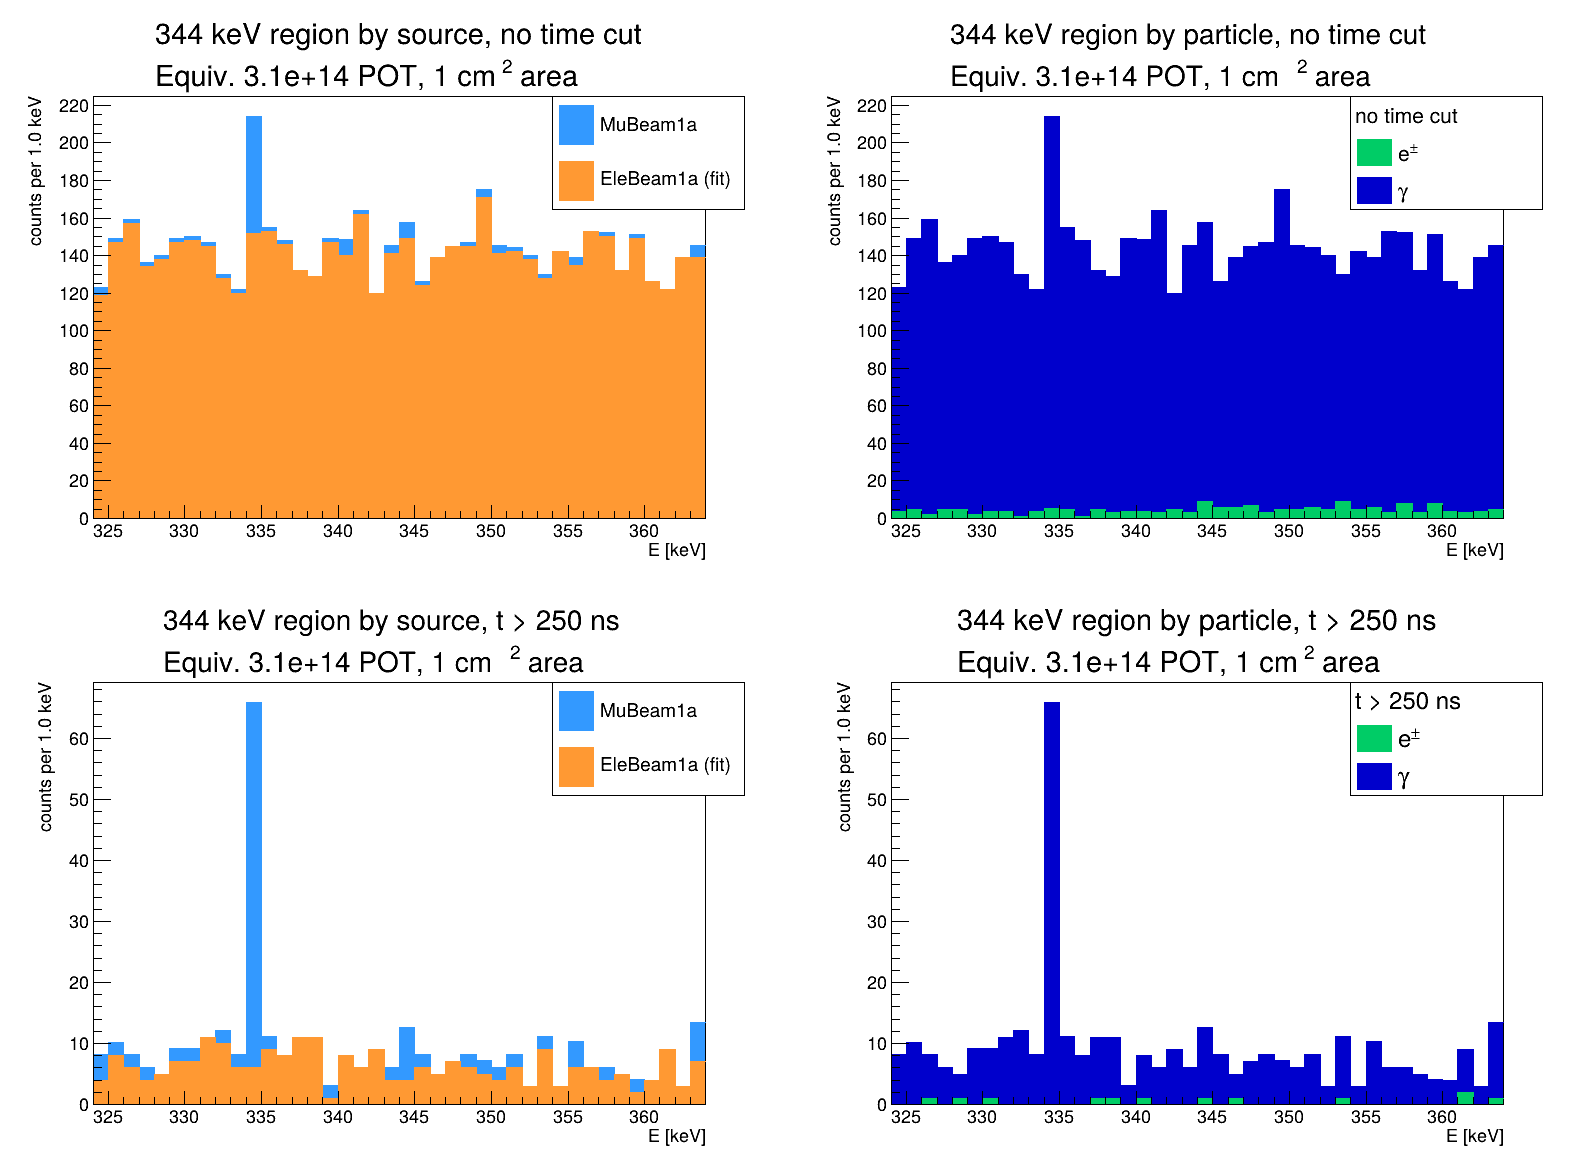

In [44]:
# ---- 344 keV gamma, run1a background only (no signal component) ----
# Same construction as the 1809 plot, but repeated for both Ele time selections:
# rows = no time cut / t > 250 ns, columns = by source / by particle.
E_344      = 344.
halfwin344 = 20.
nbins344   = 40
binsize344 = 2.*halfwin344/nbins344
lo344, hi344 = E_344-halfwin344, E_344+halfwin344

# bottom-to-top order in the stack
stack_order = ["EleBeam1a"] + mc_tags

# time cut applied to the MC components, matching the Ele fit's "tcut" selection
tsel_list = [("all",  None,          "no time cut"),
             ("tcut", "time > 250.", "t > 250 ns")]

def book344(name, title):
    return ((name, title+";E [keV];counts per %.1f keV" % binsize344,
             nbins344, lo344, hi344), "Ek")

def ele_from_fit344(name, group_name, tsel, color, rng_l):
    """Evaluate the fitted Ele continuum on the 344 binning and Poisson-smear it."""
    d = ele_fits[(group_name, tsel)]
    f = d["f"]
    p0, p1, p2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    h = ROOT.TH1D(name, "EleBeam1a %s (fit);E [keV];counts per %.1f keV" % (group_name, binsize344),
                  nbins344, lo344, hi344)
    h.SetDirectory(0)
    for ib in range(1, nbins344+1):
        # fit normalization is per fit_binsize; rescale to this bin width
        mu = (np.exp(p0 + p1*h.GetBinCenter(ib)) + p2)*ele_weight*(binsize344/fit_binsize)
        mu = max(mu, 0.)
        n = rng_l.poisson(mu)
        h.SetBinContent(ib, n)
        h.SetBinError(ib, np.sqrt(n))
    h.SetFillColor(color)
    h.SetLineColor(color)
    return h

# build both time selections
h344_bytag = {}   # (tsel, tag)   -> TH1D
h344_bygrp = {}   # (tsel, group) -> TH1D

for tsel, tcut, tlabel in tsel_list:
    rng_l = np.random.default_rng(31415)   # same seed per selection: differences are the fit, not the throw

    # --- MC components ---
    for tag in mc_tags:
        v = event_dict[tag]
        rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
        rdf = rdf.Filter("virtualdetectorId == 101") \
                 .Filter(pdgId_cut) \
                 .Filter("pz > 0.") \
                 .Define("Ek", "1000.*E") \
                 .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                         % (hole_X, hole_X, hole_Y, hole_Y)) \
                 .Filter("dr < %f" % hole_radius)
        if tcut is not None:
            rdf = rdf.Filter(tcut)

        ptr_tag = rdf.Histo1D(*book344("h344_%s_%s" % (tsel, tag), tag))
        ptrs_grp = {}
        for g in grp_list:
            gcut = "(" + " || ".join("pdgId == %d" % p for p in grp_pids[g]) + ")"
            ptrs_grp[g] = rdf.Filter(gcut).Histo1D(
                *book344("h344_%s_%s_%s" % (tsel, tag, g), grp_names[g]))

        h = ptr_tag.GetValue()
        h.SetDirectory(0)
        h.Scale(v["weight"])
        h.SetFillColor(tag_colors[tag])
        h.SetLineColor(tag_colors[tag])
        h344_bytag[(tsel, tag)] = h
        print("344 %-5s %-12s entries: %6d, weighted: %.4g"
              % (tsel, tag, h.GetEntries(), h.Integral()))

        for g, ptr in ptrs_grp.items():
            hp = ptr.GetValue()
            hp.SetDirectory(0)
            hp.Scale(v["weight"])
            key = (tsel, g)
            if key not in h344_bygrp:
                hp.SetName("h344_%s_grp_%s" % (tsel, g))
                hp.SetFillColor(grp_colors[g])
                hp.SetLineColor(grp_colors[g])
                h344_bygrp[key] = hp
            else:
                h344_bygrp[key].Add(hp)

    # --- EleBeam1a from the fit for this time selection ---
    ele_grp = {g: ele_from_fit344("h344_%s_ele_%s" % (tsel, g), g, tsel, grp_colors[g], rng_l)
               for g in grp_list}

    h_ele = ele_grp["photon"].Clone("h344_%s_EleBeam1a" % tsel)
    h_ele.SetDirectory(0)
    h_ele.Add(ele_grp["epm"])
    h_ele.SetFillColor(tag_colors["EleBeam1a"])
    h_ele.SetLineColor(tag_colors["EleBeam1a"])
    h344_bytag[(tsel, "EleBeam1a")] = h_ele
    print("344 %-5s %-12s from fit, weighted: %.4g" % (tsel, "EleBeam1a", h_ele.Integral()))

    for g in grp_list:
        add = ele_grp[g].Clone("h344_%s_eleadd_%s" % (tsel, g))
        add.SetDirectory(0)
        key = (tsel, g)
        if key not in h344_bygrp:
            add.SetName("h344_%s_grp_%s" % (tsel, g))
            add.SetFillColor(grp_colors[g])
            add.SetLineColor(grp_colors[g])
            h344_bygrp[key] = add
        else:
            h344_bygrp[key].Add(add)

# ---- draw: 2 rows (time selection) x 2 cols (by source / by particle) ----
c344 = ROOT.TCanvas("c344", "c344", 1600, 1200)
c344.Divide(2, 2)
keep344 = []
ipad = 0

for tsel, tcut, tlabel in tsel_list:
    # left: by source
    ipad += 1
    thispad = c344.cd(ipad)
    thispad.SetTopMargin(0.15)
    hs = ROOT.THStack("hs344_tag_%s" % tsel,
                      "#splitline{344 keV region by source, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (tlabel, nNorm, binsize344))
    for tag in stack_order:
        hs.Add(h344_bytag[(tsel, tag)])
    hs.Draw("hist")
    leg = ROOT.TLegend(0.70, 0.65, 0.95, 0.85)
    for tag in reversed(stack_order):
        label = tag
        if tag == "EleBeam1a":
            label += " (fit)"
        leg.AddEntry(h344_bytag[(tsel, tag)], label, "f")
    leg.Draw()
    keep344 += [hs, leg]

    # right: by particle
    ipad += 1
    thispad = c344.cd(ipad)
    thispad.SetTopMargin(0.15)
    hsg = ROOT.THStack("hs344_grp_%s" % tsel,
                       "#splitline{344 keV region by particle, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                       % (tlabel, nNorm, binsize344))
    for g in grp_list:
        hsg.Add(h344_bygrp[(tsel, g)])
    hsg.Draw("hist")
    legg = ROOT.TLegend(0.70, 0.65, 0.95, 0.85)
    for g in grp_list:
        legg.AddEntry(h344_bygrp[(tsel, g)], grp_names[g], "f")
    legg.SetHeader(tlabel)
    legg.Draw()
    keep344 += [hsg, legg]

c344.Draw()

for tsel, tcut, tlabel in tsel_list:
    nB_tag = sum(h344_bytag[(tsel, t)].Integral() for t in bkgd_tags)
    nB_grp = sum(h344_bygrp[(tsel, g)].Integral() for g in grp_list)
    print("344 %-5s (%s): B by source = %.6g, B by particle = %.6g"
          % (tsel, tlabel, nB_tag, nB_grp))

In [ ]:
# fit the excess in bin [334, 335) (for MuBeam1a and gamma), and treat that number as the number of singal events. draw smearing with both detector resolution.

LaBr3 N(1809) into aperture = 509.4 (sigma 15.0 keV, scale 1.001 x 509 throws)
LaBr all   MuBeam1a     entries in window:     2996, weighted: 40.63
LaBr all   EleBeam1a    from fit, weighted: 4836
LaBr tcut  MuBeam1a     entries in window:     1998, weighted: 25.66
LaBr tcut  EleBeam1a    from fit, weighted: 147
LaBr all   (no time cut): S = 509.4, B = 4877, S/B = 0.1045, S/sqrt(B) = 7.294
      cross-check: B by source = 4876.63, B by particle = 4876.63
LaBr tcut  (t > 250 ns ): S = 463.5, B = 172.7, S/B = 2.685, S/sqrt(B) = 35.28
      cross-check: B by source = 172.658, B by particle = 172.658


Warning in <TCanvas::Constructor>: Deleting canvas with same name: cLabr


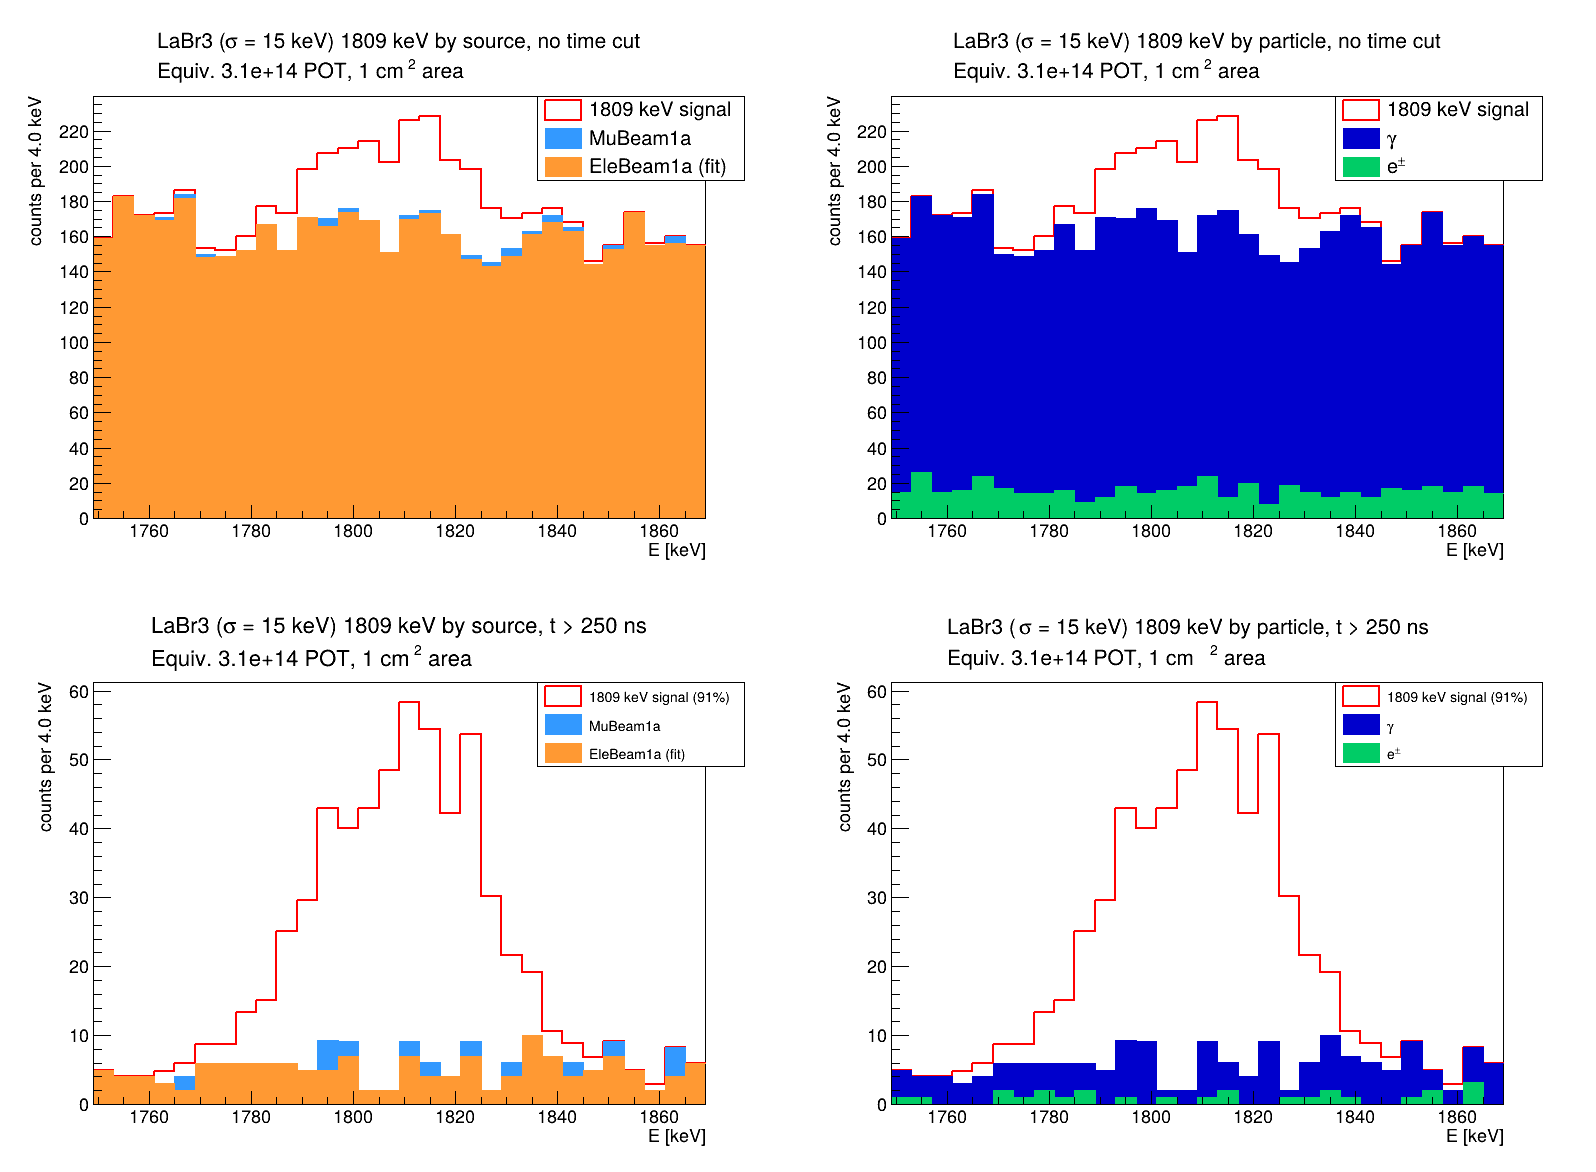

In [46]:
# ---- LaBr3: same 1809 keV signal, 15 keV resolution instead of 2.5 keV ----
# LaBr3 sits behind hole2; the aperture used here is inherited from the cells above so the
# Ele fit (done over that same selection) stays valid. Change these two and refit ele_fits
# if you want the hole2 aperture specifically.
labr_sigma  = 15.0     # keV, LaBr3 resolution
labr_hole_X = hole_X
labr_hole_Y = hole_Y
labr_radius = hole_radius

# wider window: a 15 keV sigma line needs more than +/-20 keV to contain the peak
labr_halfwin = 60.
labr_nbins   = 30
labr_binsize = 2.*labr_halfwin/labr_nbins
labr_lo, labr_hi = E_1809-labr_halfwin, E_1809+labr_halfwin

def book_labr(name, title):
    return ((name, title+";E [keV];counts per %.1f keV" % labr_binsize,
             labr_nbins, labr_lo, labr_hi), "Ek")

# ---- signal at 15 keV resolution ----
h_labr_sgnl = ROOT.TH1D("h_labr_sgnl",
                        "1809 keV line, LaBr3;E [keV];counts per %.1f keV" % labr_binsize,
                        labr_nbins, labr_lo, labr_hi)
h_labr_sgnl.SetDirectory(0)

nSgnl_labr = n1809atVD101(labr_radius)
nThrow_labr = int(min(nSgnl_labr, 1000000))
labr_scale  = nSgnl_labr/float(nThrow_labr)
rng_labr = np.random.default_rng(54321)
for E in rng_labr.normal(E_1809, labr_sigma, nThrow_labr):
    h_labr_sgnl.Fill(E)
h_labr_sgnl.Scale(labr_scale)
print("LaBr3 N(1809) into aperture = %.4g (sigma %.1f keV, scale %.4g x %d throws)"
      % (nSgnl_labr, labr_sigma, labr_scale, nThrow_labr))

# ---- Ele component from the fit, on the LaBr3 binning ----
def ele_from_fit_labr(name, group_name, tsel, color, rng_l):
    d = ele_fits[(group_name, tsel)]
    f = d["f"]
    p0, p1, p2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    h = ROOT.TH1D(name, "EleBeam1a %s (fit);E [keV];counts per %.1f keV" % (group_name, labr_binsize),
                  labr_nbins, labr_lo, labr_hi)
    h.SetDirectory(0)
    for ib in range(1, labr_nbins+1):
        # fit normalization is per fit_binsize; rescale to this bin width
        mu = (np.exp(p0 + p1*h.GetBinCenter(ib)) + p2)*ele_weight*(labr_binsize/fit_binsize)
        mu = max(mu, 0.)
        n = rng_l.poisson(mu)
        h.SetBinContent(ib, n)
        h.SetBinError(ib, np.sqrt(n))
    h.SetFillColor(color)
    h.SetLineColor(color)
    return h

hL_bytag  = {}   # (tsel, tag)   -> TH1D
hL_bygrp  = {}   # (tsel, group) -> TH1D
hL_sgnl_t = {}   # tsel -> TH1D

for tsel, tcut, tlabel in tsel_list:
    rng_l = np.random.default_rng(13579)

    # signal, scaled by the surviving fraction (same 91% as the HPGe case)
    hsig = h_labr_sgnl.Clone("h_labr_sgnl_%s" % tsel)
    hsig.SetDirectory(0)
    hsig.Scale(sgnl_eff[tsel])
    hsig.SetLineColor(ROOT.kRed)
    hsig.SetLineWidth(2)
    hL_sgnl_t[tsel] = hsig

    # ---- MC-derived components ----
    for tag in mc_tags:
        v = event_dict[tag]
        rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
        rdf = rdf.Filter("virtualdetectorId == 101") \
                 .Filter(pdgId_cut) \
                 .Filter("pz > 0.") \
                 .Define("Ek", "1000.*E") \
                 .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                         % (labr_hole_X, labr_hole_X, labr_hole_Y, labr_hole_Y)) \
                 .Filter("dr < %f" % labr_radius)
        if tcut is not None:
            rdf = rdf.Filter(tcut)

        ptr_tag = rdf.Histo1D(*book_labr("h_labr_%s_%s" % (tsel, tag), tag))
        ptrs_grp = {}
        for g in grp_list:
            gcut = "(" + " || ".join("pdgId == %d" % p for p in grp_pids[g]) + ")"
            ptrs_grp[g] = rdf.Filter(gcut).Histo1D(
                *book_labr("h_labr_%s_%s_%s" % (tsel, tag, g), grp_names[g]))

        h = ptr_tag.GetValue()
        h.SetDirectory(0)
        h.Scale(v["weight"])
        h.SetFillColor(tag_colors[tag])
        h.SetLineColor(tag_colors[tag])
        hL_bytag[(tsel, tag)] = h
        print("LaBr %-5s %-12s entries in window: %8d, weighted: %.4g"
              % (tsel, tag, h.GetEntries(), h.Integral()))

        for g, ptr in ptrs_grp.items():
            hp = ptr.GetValue()
            hp.SetDirectory(0)
            hp.Scale(v["weight"])
            key = (tsel, g)
            if key not in hL_bygrp:
                hp.SetName("h_labr_%s_grp_%s" % (tsel, g))
                hp.SetFillColor(grp_colors[g])
                hp.SetLineColor(grp_colors[g])
                hL_bygrp[key] = hp
            else:
                hL_bygrp[key].Add(hp)

    # ---- EleBeam1a from the fit ----
    ele_grp = {g: ele_from_fit_labr("h_labr_%s_ele_%s" % (tsel, g), g, tsel, grp_colors[g], rng_l)
               for g in grp_list}

    h_ele = ele_grp["photon"].Clone("h_labr_%s_EleBeam1a" % tsel)
    h_ele.SetDirectory(0)
    h_ele.Add(ele_grp["epm"])
    h_ele.SetFillColor(tag_colors["EleBeam1a"])
    h_ele.SetLineColor(tag_colors["EleBeam1a"])
    hL_bytag[(tsel, "EleBeam1a")] = h_ele
    print("LaBr %-5s %-12s from fit, weighted: %.4g" % (tsel, "EleBeam1a", h_ele.Integral()))

    for g in grp_list:
        add = ele_grp[g].Clone("h_labr_%s_eleadd_%s" % (tsel, g))
        add.SetDirectory(0)
        key = (tsel, g)
        if key not in hL_bygrp:
            add.SetName("h_labr_%s_grp_%s" % (tsel, g))
            add.SetFillColor(grp_colors[g])
            add.SetLineColor(grp_colors[g])
            hL_bygrp[key] = add
        else:
            hL_bygrp[key].Add(add)

# ---- draw: 2 rows (time selection) x 2 cols (by source / by particle) ----
cLabr = ROOT.TCanvas("cLabr", "cLabr", 1600, 1200)
cLabr.Divide(2, 2)
keepLabr = []
ipad = 0

for tsel, tcut, tlabel in tsel_list:
    sgnl = hL_sgnl_t[tsel]
    slabel = "1809 keV signal" + ("" if tsel == "all" else " (%.0f%%)" % (100*sgnl_eff[tsel]))

    # left: by source
    ipad += 1
    thispad = cLabr.cd(ipad)
    thispad.SetTopMargin(0.15)
    hs = ROOT.THStack("hs_labr_tag_%s" % tsel,
                      "#splitline{LaBr3 (#sigma = %.0f keV) 1809 keV by source, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (labr_sigma, tlabel, nNorm, labr_binsize))
    for tag in stack_order:
        hs.Add(hL_bytag[(tsel, tag)])
    hs.Add(sgnl)
    hs.Draw("hist")
    leg = ROOT.TLegend(0.68, 0.7, 0.95, 0.85)
    leg.AddEntry(sgnl, slabel, "f")
    for tag in reversed(stack_order):
        leg.AddEntry(hL_bytag[(tsel, tag)],
                     tag + (" (fit)" if tag == "EleBeam1a" else ""), "f")
    leg.Draw()
    keepLabr += [hs, leg]

    # right: by particle
    ipad += 1
    thispad = cLabr.cd(ipad)
    thispad.SetTopMargin(0.15)
    hsg = ROOT.THStack("hs_labr_grp_%s" % tsel,
                       "#splitline{LaBr3 (#sigma = %.0f keV) 1809 keV by particle, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                       % (labr_sigma, tlabel, nNorm, labr_binsize))
    for g in grp_list:
        hsg.Add(hL_bygrp[(tsel, g)])
    hsg.Add(sgnl)
    hsg.Draw("hist")
    legg = ROOT.TLegend(0.68, 0.7, 0.95, 0.85)
    legg.AddEntry(sgnl, slabel, "f")
    for g in reversed(grp_list):
        legg.AddEntry(hL_bygrp[(tsel, g)], grp_names[g], "f")
    # legg.SetHeader(tlabel)
    legg.Draw()
    keepLabr += [hsg, legg]

cLabr.Draw()

for tsel, tcut, tlabel in tsel_list:
    nS     = hL_sgnl_t[tsel].Integral()
    nB     = sum(hL_bytag[(tsel, t)].Integral() for t in bkgd_tags)
    nB_grp = sum(hL_bygrp[(tsel, g)].Integral() for g in grp_list)
    print("LaBr %-5s (%-11s): S = %.4g, B = %.4g, S/B = %.4g, S/sqrt(B) = %.4g"
          % (tsel, tlabel, nS, nB, nS/nB if nB > 0 else np.inf,
             nS/np.sqrt(nB) if nB > 0 else np.inf))
    print("      cross-check: B by source = %.6g, B by particle = %.6g" % (nB, nB_grp))